In [66]:
from jqdata import *
from jqfactor import *
import jqdata
from jqfactor import *
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import jqdata
from jqfactor import *
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pandas.tseries.offsets import CustomBusinessDay
# from datetime import datetime
import datetime
import xgboost as xgb
import talib
from sklearn.preprocessing import StandardScaler         

current_date = datetime.datetime.now()
current_time = current_date.strftime("%Y-%m-%d")

#去除上市距beginDate不足3个月的股票
def delect_stop(stocks,beginDate,n=365):
    stockList=[]
    beginDate = datetime.datetime.strptime(beginDate, "%Y-%m-%d")
    for stock in stocks:
        start_date=get_security_info(stock).start_date
        if start_date<(beginDate-datetime.timedelta(days=n)).date():
            stockList.append(stock)
    return stockList
#获取股票池
def get_stock(stockPool,begin_date):
    if stockPool=='HS300':
        stockList=get_index_stocks('000300.XSHG',begin_date)
    elif stockPool=='ZZ500':
        stockList=get_index_stocks('399905.XSHE',begin_date)
    elif stockPool=='ZZ800':
        stockList=get_index_stocks('399906.XSHE',begin_date)   
    elif stockPool=='CYBZ':
        stockList=get_index_stocks('399006.XSHE',begin_date)
    elif stockPool=='ZXBZ':
        stockList=get_index_stocks('399005.XSHE',begin_date)
    elif stockPool=='A':
        stockList=get_index_stocks('000002.XSHG',begin_date)+get_index_stocks('399107.XSHE',begin_date)
        stockList = [stock for stock in stockList if not stock.startswith(('3', '68', '4', '8'))]
    elif stockPool=='AA':
        stockList=get_index_stocks('000985.XSHG',begin_date)
        stockList = [stock for stock in stockList if not stock.startswith(('3', '68', '4', '8'))]

    #剔除ST股
    st_data=get_extras('is_st',stockList, count = 1,end_date=begin_date)
    stockList = [stock for stock in stockList if not st_data[stock][0]]
    #剔除停牌、新股及退市股票
    stockList=delect_stop(stockList,begin_date)
    return stockList

stockList=get_stock('AA',current_time)


_end_date = current_date + datetime.timedelta(-2)
_end_date = _end_date.strftime("%Y-%m-%d")
print(_end_date)

DATA = []
for i in stockList:
    df = get_price(i,  frequency='1d', 
                   start_date='2023-01-01',
                   end_date=_end_date,
    #                fields=['open','close','high','low']
                   fields=['close']
                  )

    df['returns'] = df['close'].pct_change() * 100
    df = df.dropna()
#     print(df)
    # 将收益率转换为 NumPy 数组
    returns_array = df['returns'].values
    DATA.append(returns_array)

DATA = np.array(DATA)
print(DATA.shape)
max_value = np.max(DATA)
min_value = np.min(DATA)
nan_count = np.isnan(DATA).sum()

print("数组中包含 NaN 的数量:", nan_count)
print("最大值:", max_value)
print("最小值:", min_value)

2023-12-12
(3032, 228)
数组中包含 NaN 的数量: 0
最大值: 10.465116279069765
最小值: -10.416666666666663


(3032, 2)


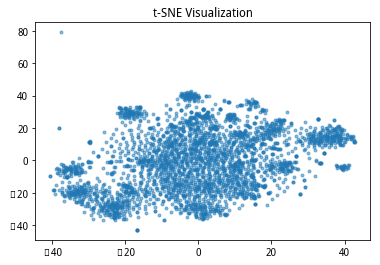

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE



# 使用 t-SNE 进行降维
tsne = TSNE(n_components=2, random_state=42)
embedded_data = tsne.fit_transform(DATA)
print(embedded_data.shape)

# 创建一个散点图进行可视化
plt.scatter(embedded_data[:, 0], embedded_data[:, 1], marker='.', alpha=0.5)
plt.title('t-SNE Visualization')
plt.show()

[[-21.70264 -25.680931]
 [16.65131 15.579328]
 [-16.783087 23.33346]
 [1.3339097 -22.49583]
 [2.7450607 30.403198]
 [-10.0765085 -3.5956128]
 [-0.3048624 8.780923]
 [-33.002975 -11.994813]
 [35.174107 11.745114]
 [14.8779545 -7.6334567]]
Cluster 1 center sample ID: 2985
Cluster 2 center sample ID: 2850
Cluster 3 center sample ID: 1791
Cluster 4 center sample ID: 1217
Cluster 5 center sample ID: 599
Cluster 6 center sample ID: 2812
Cluster 7 center sample ID: 2748
Cluster 8 center sample ID: 2590
Cluster 9 center sample ID: 2969
Cluster 10 center sample ID: 2437


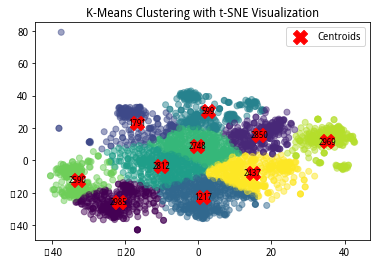

In [70]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances_argmin_min
# 假设您的数据存储在名为DATA的NumPy数组中，其形状为(3032, 225)
# 请替换为您的实际数据


# 提取降维后的坐标
x = embedded_data[:, 0]
y = embedded_data[:, 1]

# 初始化K均值模型
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

# 用K均值对降维后的数据进行聚类
labels = kmeans.fit_predict(embedded_data)
# 提取簇中心坐标
cluster_centers = kmeans.cluster_centers_
print(cluster_centers)

center_sample_indices, _ = pairwise_distances_argmin_min(cluster_centers, embedded_data)


# 输出每个簇中心样本的ID
for i, index in enumerate(center_sample_indices):
    print(f"Cluster {i + 1} center sample ID: {index}")

# 绘制散点图，并按簇着色
plt.scatter(x, y, c=labels, cmap='viridis', alpha=0.5)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='X', s=200, color='red', label='Centroids')

# 标记每个簇的中心样本ID
ID = []
for i, index in enumerate(center_sample_indices):
    plt.text(cluster_centers[i, 0], cluster_centers[i, 1], str(index), fontsize=8, ha='center', va='center', color='black')
    ID.append(index)
    
plt.title('K-Means Clustering with t-SNE Visualization')
plt.legend()
plt.show()



In [71]:
# 获取一只股票的名称
def get_stock_name(code):
    return get_security_info(code).display_name

# 获取一只股票的行业
def get_stock_industry(code):
    return get_industry(code, date=None)['jq_l2']['industry_name']





LIST = []
industry = []
name =[]
for i in ID:
    LIST.append(stockList[i])
    industry.append(get_industry(stockList[i], date=_end_date)[stockList[i]]['jq_l2']['industry_name'])
    name.append(get_security_info(stockList[i]).display_name)
 
     
q = query(valuation.code, valuation.circulating_market_cap, indicator.eps).filter(
    valuation.code.in_(LIST)).order_by(valuation.circulating_market_cap.asc())
df = get_fundamentals(q)

df['name']=name
df['industry']=industry
print(df)




          code  circulating_market_cap     eps  name   industry
0  603813.XSHG                 15.1462 -0.0705  协和电子      印制电路板
1  002823.XSHE                 20.8682  0.1277  元祖股份       休闲食品
2  605258.XSHG                 24.2088  0.0729   黑牡丹      房地产开发
3  605177.XSHG                 31.4445  0.2725  凯中精密  电动机与工控自动化
4  603886.XSHG                 43.0080  1.0569  宁波银行      区域性银行
5  603686.XSHG                 43.1451  0.1316  原尚股份       物流综合
6  603322.XSHG                 58.4770  0.0505   福龙马       市政环卫
7  600510.XSHG                 58.6703  0.2593  超讯通信     通信技术服务
8  603077.XSHG                208.4175  0.0456  东亚药业        原料药
9  002142.XSHE               1332.1523  0.9695  和邦生物         农药
